In [3]:
import pandas as pd
import numpy as np

In [4]:
# 数据集划分：将数据分成训练集（训练模型）和测试集（验证模型）
from sklearn.model_selection import train_test_split

# 数据预处理：特征标准化（统一量纲）
from sklearn.preprocessing import StandardScaler

# 回归算法模型：线性回归、随机森林回归、XGBoost回归
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# 分类算法模型：逻辑回归（二分类）
from sklearn.linear_model import LogisticRegression

# 模型评估指标：回归和分类专用指标
from sklearn.metrics import mean_squared_error, r2_score  # 回归指标（MSE、R²）
from sklearn.metrics import accuracy_score, confusion_matrix  # 分类指标

# 数据可视化：绘制图表，直观查看结果
import matplotlib.pyplot as plt
import seaborn as sns

# 忽略无关警告（避免代码运行时出现多余警告，不影响结果）
import warnings
warnings.filterwarnings('ignore')

# 设置可视化样式：显示中文、取消负号乱码（必加，否则图表中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


数据集形状（样本数×特征数）： (442, 11)
数据集缺失值检查： age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


<Figure size 1000x800 with 0 Axes>

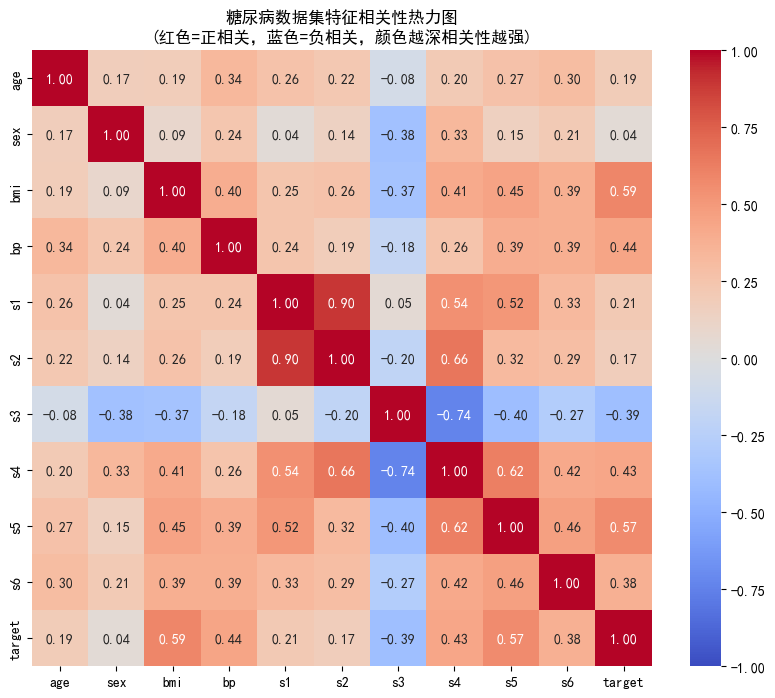

In [5]:
from sklearn.datasets import load_diabetes

# 加载糖尿病数据集
diabetes = load_diabetes()

# 转换为DataFrame格式（类似Excel表格），便于查看和处理数据
diabetes_df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
# 添加目标变量（病情指标）列，便于后续分析
diabetes_df['target'] = diabetes.target

print('数据集形状（样本数×特征数）：', diabetes_df.shape)  # 查看数据量
print('数据集缺失值检查：', diabetes_df.isnull().sum())  # 查看是否有缺失值（均为0）

# 提取特征矩阵X（所有特征）和目标变量y（病情指标），为后续模型训练做准备
X = diabetes_df.drop('target', axis=1)  # 去掉病情列，剩下的都是特征
y = diabetes_df['target']  # 病情列作为目标变量

# 简单查看特征与病情的相关性（热力图，直观易懂）
plt.figure(figsize=(10, 8))

# 计算特征间的相关系数（取值范围：-1到1）
# 1.0 = 完全正相关（同增同减）
# -1.0 = 完全负相关（此消彼长）
# 0 = 不相关
correlation_matrix = diabetes_df.corr()

# 绘制热力图
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True,      # 显示数字
            cmap='coolwarm', # 红色=正相关，蓝色=负相关
            fmt='.2f',       # 保留2位小数
            center=0,        # 颜色中点设为0
            vmin=-1, vmax=1) # 固定范围-1到1
plt.title('糖尿病数据集特征相关性热力图\n(红色=正相关，蓝色=负相关，颜色越深相关性越强)')
plt.show()


In [6]:
# 初始化标准化器（用于统一特征量纲，让算法训练更准确）
scaler = StandardScaler()

# 对特征矩阵X进行标准化处理（只标准化特征，不标准化目标变量y）
X_scaled = scaler.fit_transform(X)

# 查看标准化效果
print('标准化前特征均值（示例）：', X.iloc[:,0].mean())
print('标准化后特征均值（示例）：', round(X_scaled[:,0].mean(), 2))  
# 数据集划分：训练集70%，测试集30%
# random_state=42：保证每次运行代码，划分结果都一样（便于复现）
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# 打印划分后的数据量
print('训练集样本数：', X_train.shape[0])
print('测试集样本数：', X_test.shape[0])


标准化前特征均值（示例）： -2.511816797794472e-19
标准化后特征均值（示例）： 0.0
训练集样本数： 309
测试集样本数： 133


In [8]:
# 1. 训练线性回归模型
lr = LinearRegression()
lr.fit(X_train, y_train)  # 用训练集训练模型
print('线性回归模型训练完成！')

# 2. 训练随机森林回归模型
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
print('随机森林回归模型训练完成！')

# 3. 训练XGBoost回归模型
xgb_reg = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')
xgb_reg.fit(X_train, y_train)
print('XGBoost回归模型训练完成！')


线性回归模型训练完成！
随机森林回归模型训练完成！
XGBoost回归模型训练完成！



线性回归评估结果：
均方误差（MSE）：2821.7510（越小越好）
决定系数（R²）：0.4773（越接近1越好）

随机森林回归评估结果：
均方误差（MSE）：2875.0437（越小越好）
决定系数（R²）：0.4674（越接近1越好）

XGBoost回归评估结果：
均方误差（MSE）：3513.6592（越小越好）
决定系数（R²）：0.3491（越接近1越好）


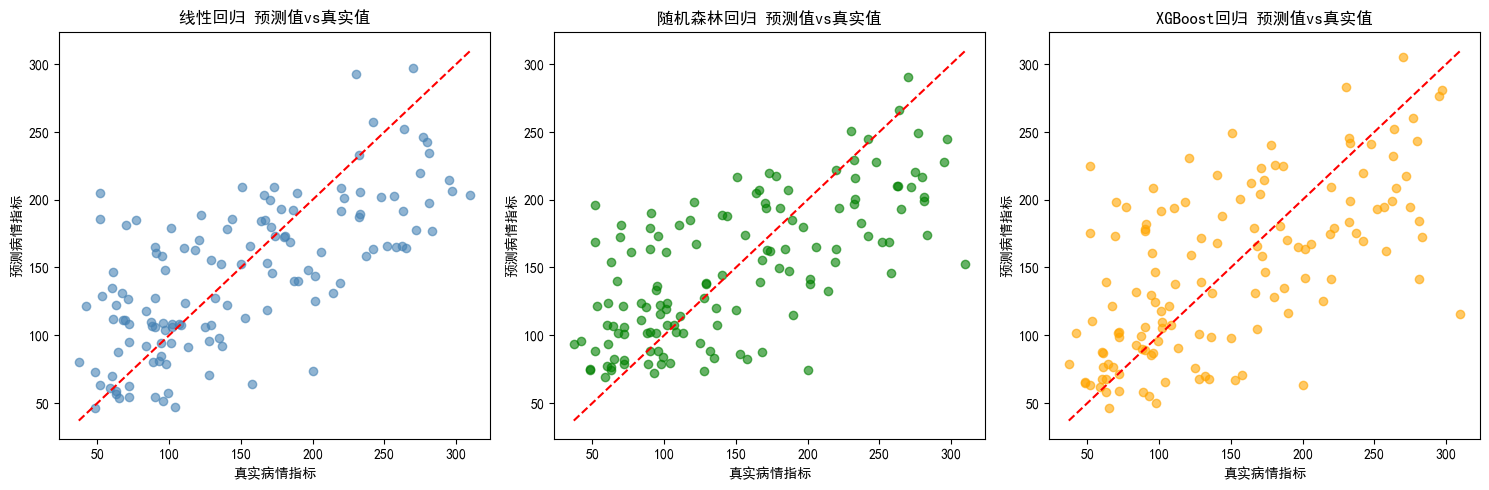

In [9]:
# 定义评估函数
def evaluate_model(model, model_name):
    y_pred = model.predict(X_test)  # 用模型预测测试集病情指标
    mse = mean_squared_error(y_test, y_pred)  # 计算MSE
    r2 = r2_score(y_test, y_pred)  # 计算R²
    print(f'\n{model_name}评估结果：')
    print(f'均方误差（MSE）：{mse:.4f}（越小越好）')
    print(f'决定系数（R²）：{r2:.4f}（越接近1越好）')
    return y_pred

# 评估三个模型，得到预测值（用于后续绘图）
y_pred_lr = evaluate_model(lr, '线性回归')
y_pred_rf = evaluate_model(rf, '随机森林回归')
y_pred_xgb = evaluate_model(xgb_reg, 'XGBoost回归')

# 可视化：只绘制预测值与真实值对比（直观查看预测效果）
plt.figure(figsize=(15, 5))

# 线性回归预测图
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 完美预测线
plt.xlabel('真实病情指标')
plt.ylabel('预测病情指标')
plt.title('线性回归 预测值vs真实值')

# 随机森林回归预测图
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('真实病情指标')
plt.ylabel('预测病情指标')
plt.title('随机森林回归 预测值vs真实值')

# XGBoost回归预测图
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_xgb, alpha=0.6, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('真实病情指标')
plt.ylabel('预测病情指标')
plt.title('XGBoost回归 预测值vs真实值')

plt.tight_layout()
plt.show()
